Test the perturbed slab model created.

In [4]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import numpy as np
from fields.slab_bfield_two_pert import SlabBfieldTwoPert
from pyoculus.maps import ToroidalBfieldSection
# from maps.toroidal_bfield_section_mod import ToroidalBfieldSection   # Note: modified import for the domain
from pyoculus.solvers import PoincarePlot, FixedPoint
import matplotlib.pyplot as plt

#### Create the magnetic field:

In [7]:
field = SlabBfieldTwoPert(
    m1=1,
    n1=1,
    delta1=0.01,
    m2=1,
    n2=-1,
    delta2=0.01,
    iota_prime=2.0,
    x0=1.0,
)

coords = np.array([0.4, 0.2, 0.3])

print("B:")
print(field.B(coords))

print("\nB and dBdX:")
B, dBdX = field.dBdX(coords)

print(B)
print(dBdX)

xs1 = field.x0 + field.n1 / (field.iota_prime * field.m1)
xs2 = field.x0 + field.n2 / (field.iota_prime * field.m2)

print("The islands will be situated at x_s =", xs1, xs2)

B:
[ 6.07347395e-04 -1.19438224e+00  1.00000000e+00]

B and dBdX:
[ 6.07347395e-04 -1.19438224e+00  1.00000000e+00]
[[ 1.13877637e-03  2.99613876e-03 -1.87874565e-04]
 [ 1.99063707e+00 -1.13877637e-03 -1.73777687e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]
The islands will be situated at x_s = 1.5 0.5


#### Create the map:

In [8]:
map = ToroidalBfieldSection(field, domain=[(0, 2), (0, 2*np.pi)])
# map = ToroidalBfieldSection(field)

In [5]:
x0 = np.array([1.43, 0.2])
x1 = map.f(1, x0)
x2 = map.f(1, x1)

print("Initial point:")
print(x0)

print("After one map iteration:")
print(x1)

print("After two map iterations:")
print(x2)

Initial point:
[1.43 0.2 ]
After one map iteration:
[1.4303061  5.62604152]
After two map iterations:
[1.43150068 4.76756004]


#### Create Poincaré plot:

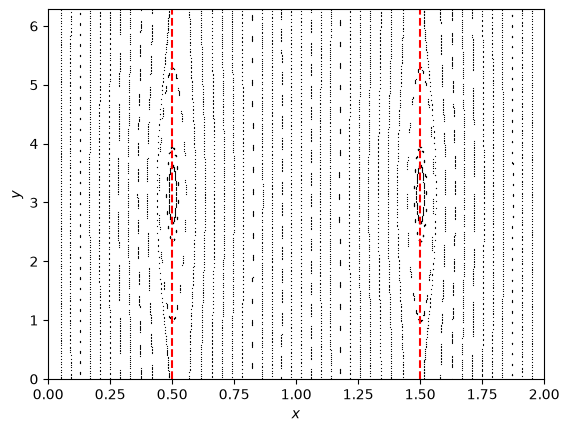

In [9]:
pplot = PoincarePlot.with_linspace(
    map,
    np.array([0.05, np.pi]),
    np.array([1.95, np.pi]),
    npts=50
)

# Follow each initial condition for 200 crossings
pplot.compute(npts=150)

# Plot directly in (x,y) coordinates
fig, ax = pplot.plot(plottype=None) # plottypeNone to directly plot in the coordinates of the map

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xlim(0, 2)
ax.set_ylim(0, 2*np.pi)

ax.axvline(
    xs1,
    linestyle="--",
    label=rf"$x_s1={xs1:.3f}$",
    color="r"
)
ax.axvline(
    xs2,
    linestyle="--",
    label=rf"$x_s2={xs2:.3f}$",
    color="r"
)
plt.show()

#### Find fixed points:

In [10]:
fp = FixedPoint(map)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

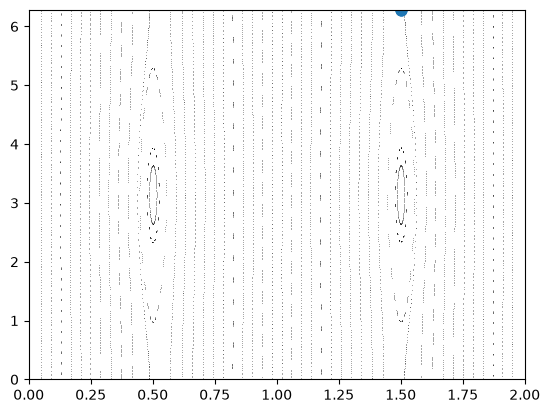

In [11]:
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 2],
    ylim=[0, 2*np.pi],
    plottype=None
)


fp = FixedPoint(map)

result = fp.find_with_iota(
    n = field.n1,
    m = field.m1,
    guess = np.array([0.5, 0.]),
    method="scipy.root"
)   

fp.plot(
    fig=fig,
    ax=ax,
    marker="o",
    s=60,
    plottype=None
)

#### Wrong cases:

```fp.find(t=t,...)``` doesn't always work: sometimes we stumble upon t-cycles that aren't fixed points.

[[1. 0.]
 [1. 0.]]
[[1. 0.]
 [1. 0.]
 [1. 0.]]
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


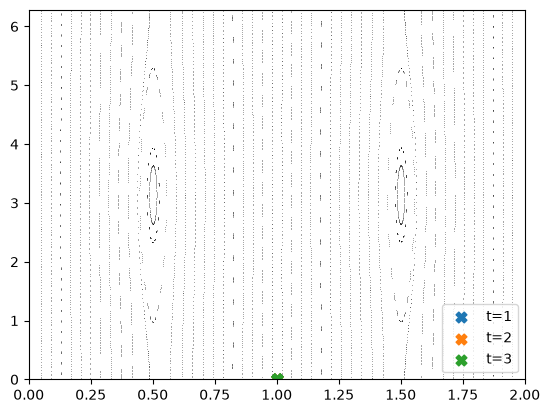

In [47]:
guess = np.array([1., 0.])
fig, ax = pplot.plot(
    marker=".",
    s=0.5,
    xlim=[0, 2.],
    ylim=[0, 2*np.pi],
    plottype=None
)

for t in [1,2,3]:
    fp = FixedPoint(map)
    result = fp.find(
        t=t,                    # t-order fixed points
        guess=guess,
        method="scipy.root"
    ) 
    print(result.coords)     

    fp.plot(
        fig=fig,
        ax=ax,
        marker="X",
        s=60,
        label=f"t={t}",
        plottype=None
    )

plt.legend(loc="lower right")
plt.show()
